In [3]:
library(tidyverse)
library(ape)
library(TreeSim)
library(phytools)
library(phylolm)
library(TreeTools)
library(tibble)
library(dplyr)
library(readr)
library(data.table)
library(gridExtra)
library(svglite)

In [75]:
num_rep = 500
n_tips = 2 ** c(3:10)
n_PCs = n_tips / 2 - 1
n_PCs [n_PCs > 50] = 50
n_size = length(n_tips)
betas = 2 ** c(-4:1)
n_beta = length(betas)
n_rows = num_rep * (sum(n_PCs) + n_size) * n_beta

In [76]:
p_vals_PC = data.table(
    PCs = numeric(n_rows),
    p.value = numeric(n_rows),  
    tips = numeric(n_rows), 
    beta.size = numeric(n_rows)
)

set.seed(42)

counter = 1
for (i in 1:n_size) {
    message("Testing for tip number: ", i)
    n_tip = n_tips[i]
    n_PC = n_PCs[i]

    tree = sim.bd.taxa(n_tip,1,1,0,1,complete=FALSE)[[1]]
    tree$root.edge=0
    PCs = eigen(vcv(tree))$vectors

    colnames(PCs) = paste0("PC_",1:ncol(PCs))
    PCs = as_tibble(PCs)

    
    PC_sets = lapply(1:n_PC,function(i){paste0("PC_",1:i)})
    PC_sets = c("1",PC_sets) 

    for (j in 1:num_rep) {
        if (j %% 10 == 0) {message("repeat: ", j)}
        
        for (k in 1:n_beta) {
            beta = betas[k]

            BM = fastBM(tree,1,nsim=2)
            X = BM[,1]
            Y = X * beta + BM[,2]
    
            all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
    
            rownames(all_data) = rownames(BM)
            

            for (l in 1:length(PC_sets)) {
                cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[l]]),collapse=" + "))
                
                tryCatch({
                    cur_lm = phylolm(cur_formula,data=all_data,phy=tree)
                    cur_p = summary(cur_lm)$coefficients["X","p.value"]
                          
                    p_vals_PC[counter, `:=`("PCs" = l - 1, "p.value" = cur_p,  
                                            "tips" = n_tip, "beta.size" = beta)]
                }, error = function(e) { 
                    
                    p_vals_PC[counter, `:=`("PCs" = l - 1, "p.value" = NA, 
                                            "tips" = n_tip, "beta.size" = beta)]
                 })

                counter = counter + 1
           }      
            
       }
    
    }
}

Testing for tip number: 1

repeat: 10

repeat: 20

repeat: 30

repeat: 40

repeat: 50

repeat: 60

repeat: 70

repeat: 80

repeat: 90

repeat: 100

repeat: 110

repeat: 120

repeat: 130

repeat: 140

repeat: 150

repeat: 160

repeat: 170

repeat: 180

repeat: 190

repeat: 200

repeat: 210

repeat: 220

repeat: 230

repeat: 240

repeat: 250

repeat: 260

repeat: 270

repeat: 280

repeat: 290

repeat: 300

repeat: 310

repeat: 320

repeat: 330

repeat: 340

repeat: 350

repeat: 360

repeat: 370

repeat: 380

repeat: 390

repeat: 400

repeat: 410

repeat: 420

repeat: 430

repeat: 440

repeat: 450

repeat: 460

repeat: 470

repeat: 480

repeat: 490

repeat: 500

Testing for tip number: 2

repeat: 10

repeat: 20

repeat: 30

repeat: 40

repeat: 50

repeat: 60

repeat: 70

repeat: 80

repeat: 90

repeat: 100

repeat: 110

repeat: 120

repeat: 130

repeat: 140

repeat: 150

repeat: 160

repeat: 170

repeat: 180

repeat: 190

repeat: 200

repeat: 210

repeat: 220

repeat: 230

repeat: 240

re

In [77]:
plot_positive_yule_list = vector("list", 6)

for (i in 1:6) {
    beta = 2 ** (i - 5) 
    p_vals_PC_summary_yule = (p_vals_PC %>%
        filter(beta.size == beta) %>%
        group_by(PCs, tips) %>%
        summarise(FNR = mean(p.value<0.05), .groups = "drop"))
    
    p_vals_PC_summary_yule$tips = factor(p_vals_PC_summary_yule$tips)

    plot_positive_yule_list[[i]] <- (p_vals_PC_summary_yule %>% 
          ggplot(aes(PCs,FNR)) +
          geom_line(aes(color = tips), linewidth=2) +
          theme_classic(base_size=20) +
          ylim(0, 1) +
          theme(axis.title.x = element_blank(), axis.title.y = element_blank(), 
                axis.text.x = element_text(size = 22), axis.text.y = element_text(size = 22),
                legend.position = "none") +
          scale_color_manual(values=c("#332288", "#88CCEE", "#44AA99", "#117733",
                                      "#999933", "#DDCC77", "#CC6677", "#882255"), 
                             breaks = c("8", "16","32", "64", "128", "256", "512", "1024")))

    if (i == 1) {
        tmp <- (plot_positive_yule_list[[i]] + 
                theme(legend.position="right",
                      legend.spacing.y = unit(1,"pt"), 
                      legend.key.width = unit(2, "cm"),
                      legend.title.position = "left",
                      legend.title = element_text(size = 36, margin = margin(r = 40)), 
                      legend.text = element_text(size = 28)) + 
                guides(color = guide_legend(nrow = 1)))
        
        g_tmp <- ggplotGrob(tmp)
        legend <- g_tmp$grobs[[which(sapply(g_tmp$grobs, function(x) x$name) == "guide-box")]] 
    }
    if (i == 1 || i == 4) {
        plot_positive_yule_list[[i]] <- (plot_positive_yule_list[[i]] + 
                                         ylab("Fraction of significant tests") + 
                                         theme(axis.title.y = element_text(size = 28, 
                                                                          angle = 90, 
                                                                          vjust = 0.5)))
    }
    if (i >= 4) {
        plot_positive_yule_list[[i]] <- (plot_positive_yule_list[[i]] + 
                                         xlab("Number of eigenvectors") + 
                                         theme(axis.title.x = element_text(size = 28)))
    }
}

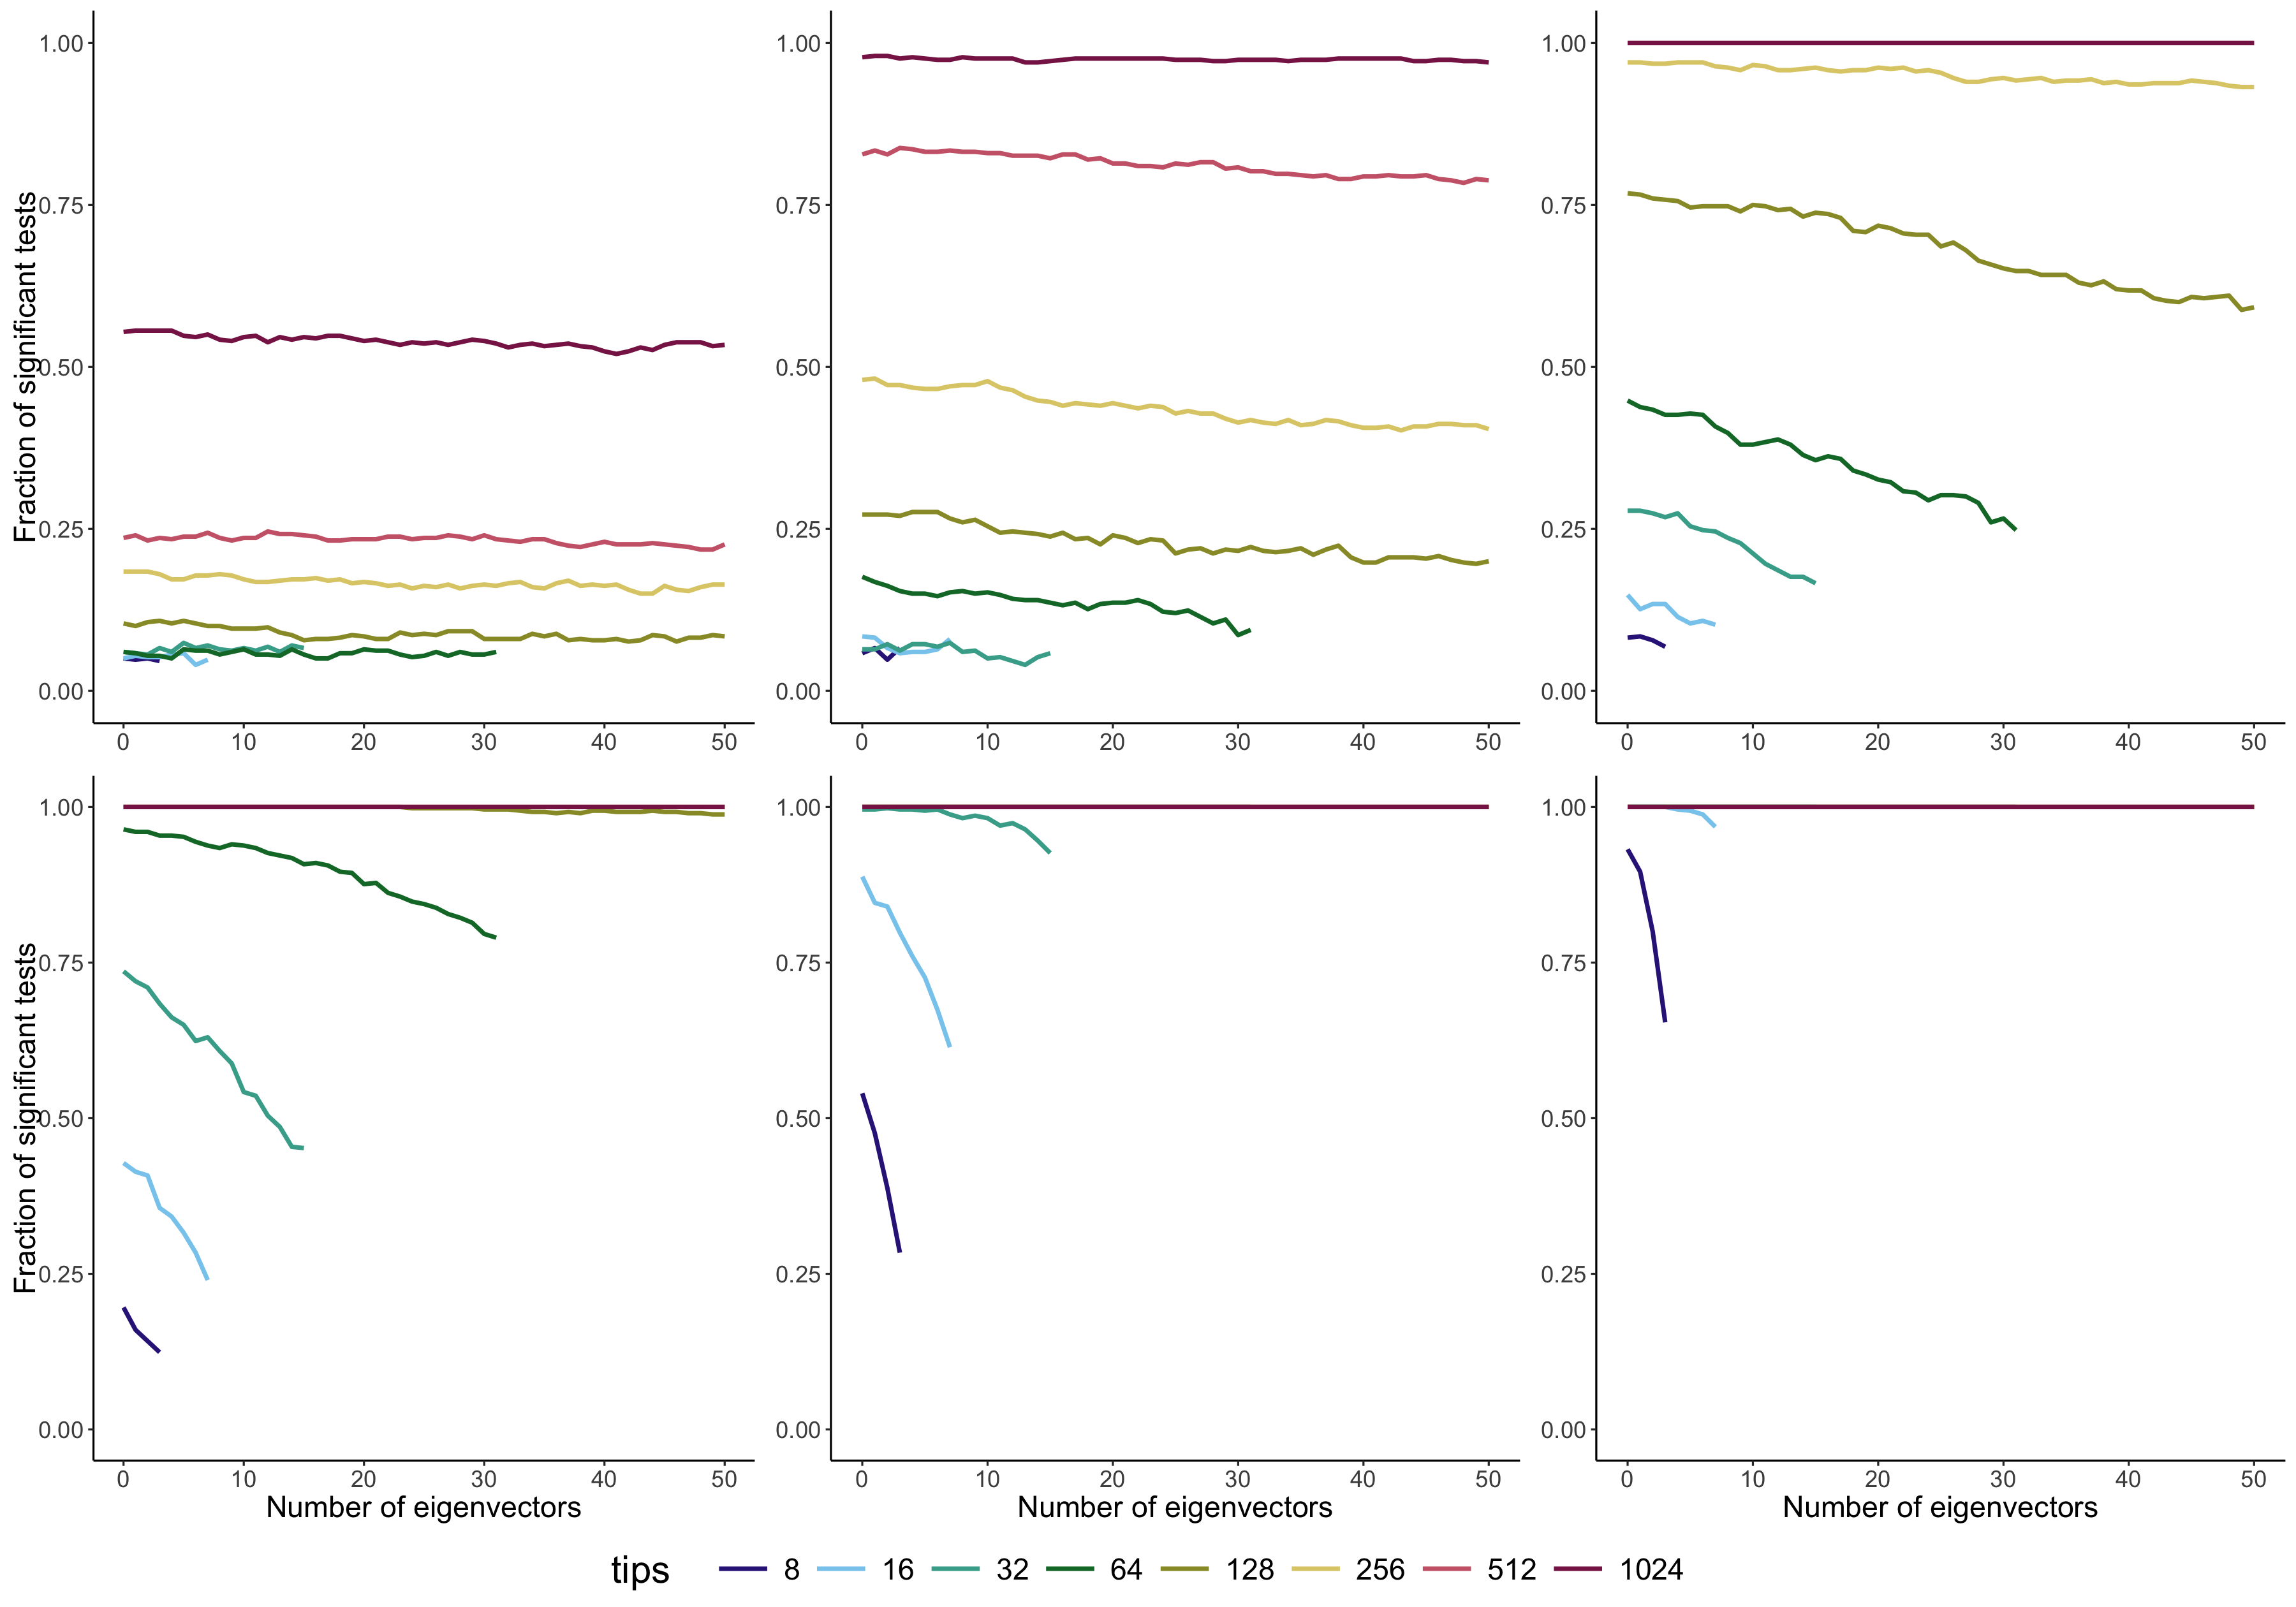

In [80]:
options(repr.plot.width = 30, repr.plot.height = 21)

# Arrange all rows into one layout
panels <- arrangeGrob(grobs = plot_positive_yule_list, 
                      ncol = 3)

g  <- grid.arrange(
  panels, legend,
  ncol = 1,
  heights = c(20, 1)  # relative width of panels vs legend
)
ggsave("Figures_raw/Scaling_positive.pdf", g, width = 30, height = 21)
ggsave("Figures_raw/Scaling_positive.svg", g, width = 30, height = 21)